In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
y_test = y_test.reshape(-1,)

In [ ]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [ ]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

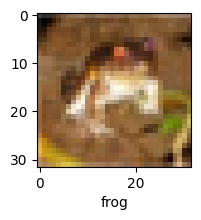

In [ ]:
plot_sample(X_train, y_train, 0)

TypeError: only integer scalar arrays can be converted to a scalar index

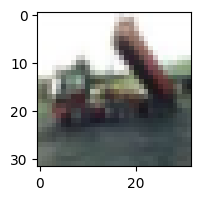

In [ ]:
plot_sample(X_train, y_train, 2)

In [ ]:
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
#normalizing training data ranging 0 to 1 as value can range from 0 - 255
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4667 - loss: 1.4888
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6056 - loss: 1.1280
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6553 - loss: 0.9926
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6863 - loss: 0.9084
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7063 - loss: 0.8456


In [ ]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6674 - loss: 0.9646


[0.9645734429359436, 0.6674000024795532]

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


array([[1.4910472e-02, 1.4838200e-03, 1.4407506e-03, 3.5834777e-01,
        7.2754704e-04, 1.9882222e-01, 3.4140281e-02, 9.1015920e-04,
        3.8874087e-01, 4.7600301e-04],
       [1.2369845e-03, 1.7528276e-01, 1.0549561e-06, 2.4525634e-06,
        4.7682807e-08, 6.0037941e-08, 1.2348521e-07, 2.4848552e-08,
        8.2301158e-01, 4.6484167e-04],
       [9.0417996e-02, 5.2587128e-01, 3.8235297e-03, 5.8989022e-03,
        4.2186308e-04, 2.6531241e-04, 5.4702302e-04, 3.4525766e-04,
        3.5727647e-01, 1.5132242e-02],
       [5.4196298e-01, 2.5751403e-01, 1.4427062e-02, 8.7849342e-04,
        1.2971954e-03, 3.2809796e-05, 2.5806816e-03, 6.9914437e-05,
        1.7708161e-01, 4.1552451e-03],
       [1.1921428e-04, 3.8441137e-04, 2.2819636e-02, 1.7633051e-02,
        4.9706528e-01, 6.7900899e-03, 4.5459825e-01, 1.7883012e-04,
        3.7907399e-04, 3.2111773e-05]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]

In [ ]:
y_classes[:5]

[np.int64(8), np.int64(8), np.int64(1), np.int64(0), np.int64(4)]

In [ ]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

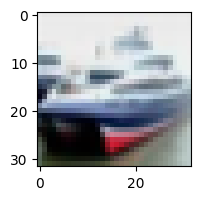

In [ ]:
plot_sample(X_test, y_test,1)

In [ ]:
classes[y_classes[1]]

'ship'

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
print("Classification Report: \n", classification_report(y_test, y_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.68      0.75      0.71      1000
           1       0.72      0.88      0.79      1000
           2       0.60      0.48      0.53      1000
           3       0.56      0.38      0.45      1000
           4       0.65      0.59      0.62      1000
           5       0.67      0.46      0.55      1000
           6       0.63      0.86      0.73      1000
           7       0.65      0.78      0.71      1000
           8       0.69      0.84      0.76      1000
           9       0.80      0.65      0.72      1000

    accuracy                           0.67     10000
   macro avg       0.66      0.67      0.66     10000
weighted avg       0.66      0.67      0.66     10000



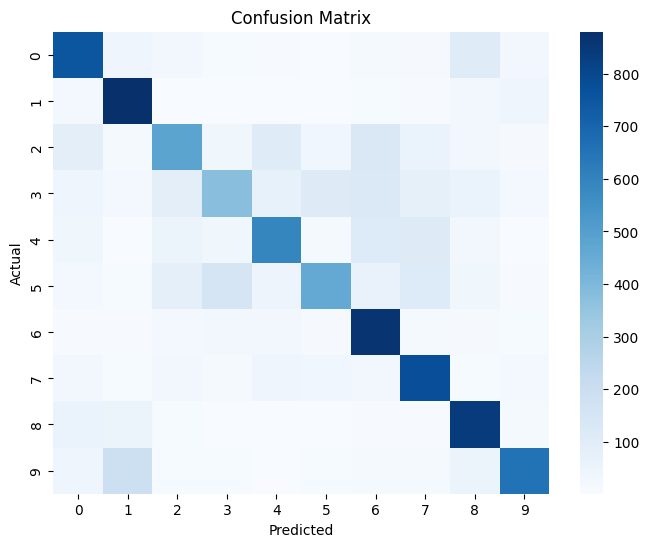

In [ ]:
#Confusion Matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()